In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fab_process_yield.csv to fab_process_yield.csv


In [ ]:
print(uploaded.keys())

dict_keys(['fab_process_yield.csv'])


In [ ]:
import pandas as pd
import numpy as np

file_name = "fab_process_yield.csv"
df = pd.read_csv(file_name)

print(df.shape)
df.head()

(1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [ ]:
time_col = "Time"
target_col = "Pass/Fail"
feature_cols = df.columns[1:-1]

X = df[feature_cols]

print("=== 열 구조 ===")
print("전체 데이터 크기:", df.shape)
print("시간 열:", df.columns[0])
print("첫 센서:", feature_cols[0])
print("마지막 센서:", feature_cols[-1])
print("센서 수:", len(feature_cols))
print("타깃 열:", df.columns[-1])

print("\n=== 라벨 분포 ===")
print(df[target_col].value_counts(dropna=False))
print((df[target_col].value_counts(normalize=True) * 100).round(2))

print("\n=== 자료형 ===")
numeric_cols = X.select_dtypes(include=np.number).columns
non_numeric_cols = X.select_dtypes(exclude=np.number).columns

print("숫자형 센서 수:", len(numeric_cols))
print("비숫자형 센서 수:", len(non_numeric_cols))
print("비숫자형 센서 목록:", non_numeric_cols.tolist())

=== 열 구조 ===
전체 데이터 크기: (1567, 592)
시간 열: Time
첫 센서: 0
마지막 센서: 589
센서 수: 590
타깃 열: Pass/Fail

=== 라벨 분포 ===
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
Pass/Fail
-1    93.36
 1     6.64
Name: proportion, dtype: float64

=== 자료형 ===
숫자형 센서 수: 590
비숫자형 센서 수: 0
비숫자형 센서 목록: []


In [ ]:
missing_count = X.isna().sum()
missing_rate = X.isna().mean()

zero_count = X.eq(0).sum()
zero_rate = X.eq(0).mean()

unique_count = X.nunique(dropna=True)
constant_cols = unique_count[unique_count <= 1].index.tolist()

print("=== 데이터 품질 ===")
print("전체 결측값 수:", int(missing_count.sum()))
print("전체 0 값 수:", int(zero_count.sum()))
print("결측이 있는 센서 수:", int((missing_count > 0).sum()))
print("결측률 20% 이상 센서 수:", int((missing_rate >= 0.20).sum()))
print("결측률 50% 이상 센서 수:", int((missing_rate >= 0.50).sum()))
print("상수 센서 수:", len(constant_cols))
print("완전 중복 행 수:", int(df.duplicated().sum()))

print("\n결측률 상위 10개 센서")
display(
    pd.DataFrame({
        "결측 개수": missing_count,
        "결측률(%)": missing_rate * 100
    }).sort_values("결측률(%)", ascending=False).head(10)
)

print("\n0 비율 상위 10개 센서")
display(
    pd.DataFrame({
        "0 개수": zero_count,
        "0 비율(%)": zero_rate * 100
    }).sort_values("0 비율(%)", ascending=False).head(10)
)

print("\n상수 센서 목록")
print(constant_cols)

=== 데이터 품질 ===
전체 결측값 수: 41951
전체 0 값 수: 200005
결측이 있는 센서 수: 538
결측률 20% 이상 센서 수: 32
결측률 50% 이상 센서 수: 28
상수 센서 수: 116
완전 중복 행 수: 0

결측률 상위 10개 센서


,결측 개수,결측률(%)
292,1429,91.193363
293,1429,91.193363
158,1429,91.193363
157,1429,91.193363
492,1341,85.577537
85,1341,85.577537
358,1341,85.577537
220,1341,85.577537
244,1018,64.964901
517,1018,64.964901



0 비율 상위 10개 센서


,0 개수,0 비율(%)
461,1566,99.936184
451,1566,99.936184
52,1566,99.936184
458,1566,99.936184
322,1566,99.936184
325,1566,99.936184
315,1566,99.936184
186,1566,99.936184
189,1566,99.936184
179,1566,99.936184



상수 센서 목록
['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']


In [ ]:
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

print("시간 변환 실패:", df["Time"].isna().sum())
print("최초 시간:", df["Time"].min())
print("최종 시간:", df["Time"].max())
print("시간순 정렬 여부:", df["Time"].is_monotonic_increasing)
print("중복 시간 수:", df["Time"].duplicated().sum())

시간 변환 실패: 0
최초 시간: 2008-01-08 02:02:00
최종 시간: 2008-12-10 18:47:00
시간순 정렬 여부: False
중복 시간 수: 33


In [ ]:
raw_df = pd.read_csv("fab_process_yield.csv")

print(raw_df["Time"].head(10).tolist())
print(raw_df["Time"].tail(10).tolist())

['2008-07-19 11:55:00', '2008-07-19 12:32:00', '2008-07-19 13:17:00', '2008-07-19 14:43:00', '2008-07-19 15:22:00', '2008-07-19 17:53:00', '2008-07-19 19:44:00', '2008-07-19 19:45:00', '2008-07-19 20:24:00', '2008-07-19 21:35:00']
['2008-10-16 05:08:00', '2008-10-16 05:13:00', '2008-10-16 05:44:00', '2008-10-16 05:58:00', '2008-10-16 15:02:00', '2008-10-16 15:13:00', '2008-10-16 20:49:00', '2008-10-17 05:26:00', '2008-10-17 06:01:00', '2008-10-17 06:07:00']


In [ ]:
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df["month"] = df["Time"].dt.to_period("M").astype(str)

print(df["month"].value_counts().sort_index())

month
2008-01     51
2008-02     98
2008-03     50
2008-04     49
2008-05     62
2008-06     67
2008-07    114
2008-08    471
2008-09    413
2008-10    123
2008-11     35
2008-12     34
Name: count, dtype: int64


In [ ]:
# 센서와 타깃 분리
feature_cols = [str(i) for i in range(590)]

# 열 이름이 정수형으로 읽혔다면 이 코드가 자동 대응
if "0" not in df.columns:
    feature_cols = list(range(590))

X = df[feature_cols]
y = df["Pass/Fail"].map({
    -1: 0,  # Pass
     1: 1   # Fail
})

print("X 크기:", X.shape)
print("y 분포:")
print(y.value_counts())
print("타깃 변환 결측:", y.isna().sum())

X 크기: (1567, 590)
y 분포:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64
타깃 변환 결측: 0


In [ ]:
# 상수 센서
constant_cols = X.columns[
    X.nunique(dropna=True) <= 1
].tolist()

# 결측률 50% 이상 센서
missing_rate = X.isna().mean()
high_missing_cols = missing_rate[
    missing_rate >= 0.50
].index.tolist()

# 중복 제거 대상 통합
drop_cols = list(set(constant_cols) | set(high_missing_cols))

X_clean = X.drop(columns=drop_cols)

print("원래 센서 수:", X.shape[1])
print("상수 센서 수:", len(constant_cols))
print("결측률 50% 이상 센서 수:", len(high_missing_cols))
print("실제 제거 센서 수:", len(drop_cols))
print("남은 센서 수:", X_clean.shape[1])
print("남은 결측값 수:", int(X_clean.isna().sum().sum()))

원래 센서 수: 590
상수 센서 수: 116
결측률 50% 이상 센서 수: 28
실제 제거 센서 수: 144
남은 센서 수: 446
남은 결측값 수: 10868


[1차 데이터 탐색 결과]

- 데이터 크기: 1,567행 × 592열
- 센서 수: 590개
- Pass: 1,463건
- Fail: 104건
- Fail 비율: 6.64%
- 전체 결측값: 41,951개
- 결측이 있는 센서: 538개
- 상수 센서: 116개
- 결측률 50% 이상 센서: 28개
- 제거 후 센서: 446개
- 제거 후 남은 결측값: 10,868개
- 완전 중복 행: 0개
- 분석 기간: 2008년 1월~12월

In [ ]:
# target 생성
y = df["Pass/Fail"].map({
    -1: 0,
     1: 1
})

print(y.value_counts())

Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [ ]:
print(X_clean.shape)

(1567, 446)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1253, 446)
(314, 446)
Pass/Fail
0    1170
1      83
Name: count, dtype: int64
Pass/Fail
0    293
1     21
Name: count, dtype: int64


In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

In [ ]:
pipe = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler()),

    ("model",
     LogisticRegression(
         class_weight="balanced",
         max_iter=3000,
         random_state=42
     ))
])

In [ ]:
pipe.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])

In [ ]:
pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

print("=== Classification Report ===")
print(classification_report(y_test, pred, digits=4))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, pred))

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred), 4))
print("Recall:", round(recall_score(y_test, pred), 4))
print("F1:", round(f1_score(y_test, pred), 4))
print("PR-AUC:", round(average_precision_score(y_test, prob), 4))

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9384    0.8840    0.9104       293
           1     0.1053    0.1905    0.1356        21

    accuracy                         0.8376       314
   macro avg     0.5218    0.5372    0.5230       314
weighted avg     0.8827    0.8376    0.8586       314

=== Confusion Matrix ===
[[259  34]
 [ 17   4]]
Accuracy: 0.8376
Precision: 0.1053
Recall: 0.1905
F1: 0.1356
PR-AUC: 0.1499


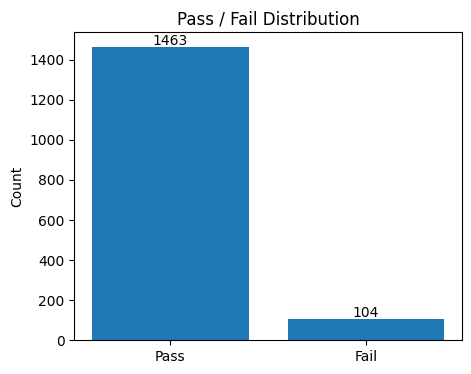

In [ ]:
import matplotlib.pyplot as plt

label_counts = y.value_counts().sort_index()

plt.figure(figsize=(5,4))
plt.bar(["Pass", "Fail"], label_counts.values)

plt.title("Pass / Fail Distribution")
plt.ylabel("Count")

for i, v in enumerate(label_counts.values):
    plt.text(i, v+10, str(v), ha="center")

plt.show()

day3

In [ ]:
# 현재 변수 확인
%whos

Variable                  Type                      Data/Info
-------------------------------------------------------------
LogisticRegression        type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                  ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier    ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SimpleImputer             type                      <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler            type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                         DataFrame                             0        1   <...>[1567 rows x 590 columns]
X_clean                   DataFrame                             0        1   <...>[1567 rows x 446 columns]
X_test                    DataFrame                             0        1   <...>n[314 rows x 446 columns]
X_train                   DataFrame        

1. Random Forest Feature Importance

이 모델을 만든 객체가 현재 변수명으로 안 남아있어, 같은 조건으로 다시 생성해서 저장

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "sensor": X_train.columns,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,sensor,importance
59,64,0.012729
60,65,0.012039
434,574,0.011008
422,562,0.009805
54,59,0.008817
341,441,0.007763
93,103,0.007641
138,153,0.007469
24,26,0.007334
399,539,0.006873


In [ ]:
[x for x in dir() if 'rf' in x.lower() or 'forest' in x.lower()]

['RandomForestClassifier', 'rf_balanced', 'rf_model']

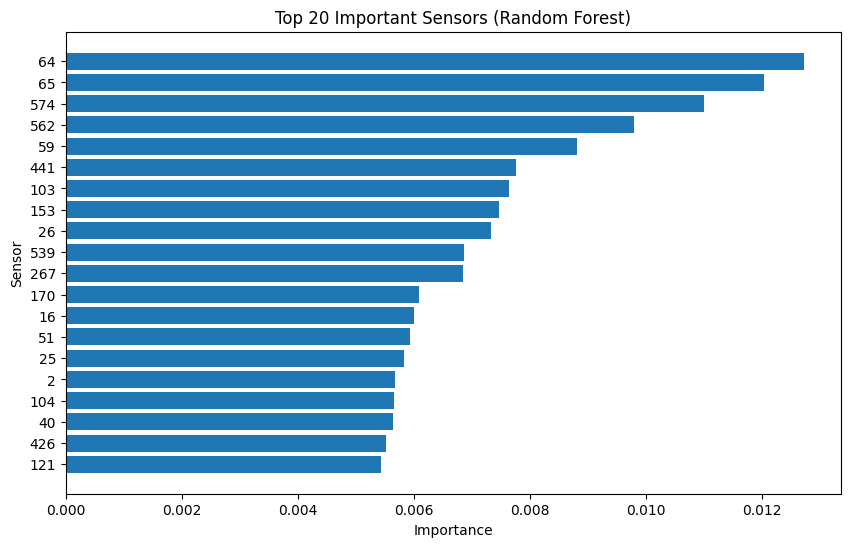

In [ ]:
plt.figure(figsize=(10,6))

top20 = feature_importance.head(20)

plt.barh(
    top20["sensor"].astype(str),
    top20["importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Sensor")
plt.title("Top 20 Important Sensors (Random Forest)")
plt.show()

In [ ]:
top_features = feature_importance.head(20)

top_features

,sensor,importance
59,64,0.012729
60,65,0.012039
434,574,0.011008
422,562,0.009805
54,59,0.008817
341,441,0.007763
93,103,0.007641
138,153,0.007469
24,26,0.007334
399,539,0.006873


In [ ]:
top_features.to_csv(
    "rf_top20_sensor_importance.csv",
    index=False
)

In [ ]:
print(rf_model)
print(rf_balanced)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)


day4

In [ ]:
!pip install shap -q

In [ ]:
import shap

# Random Forest SHAP Explainer
explainer = shap.TreeExplainer(rf_model)

# 테스트 데이터 SHAP 값 계산
shap_values = explainer.shap_values(X_test)

In [ ]:
type(shap_values), len(shap_values)

(numpy.ndarray, 314)

In [ ]:
shap_values.shape

(314, 446, 2)

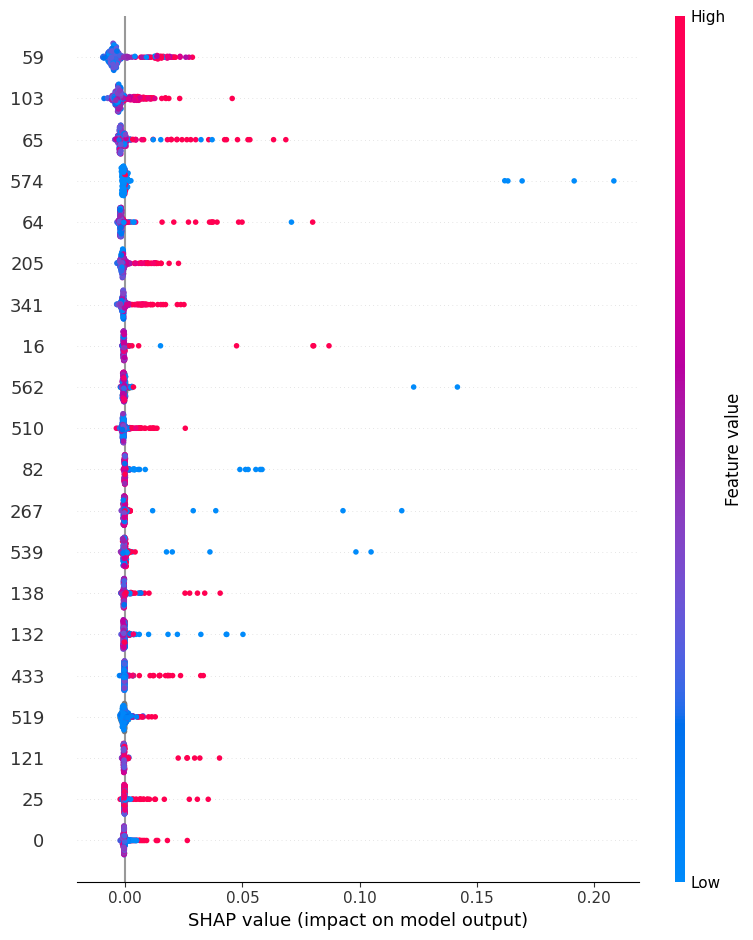

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    max_display=20
)

In [ ]:
shap_importance = pd.DataFrame({
    "sensor": X_test.columns,
    "mean_abs_shap": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="mean_abs_shap",
    ascending=False
)

shap_importance.head(20)

,sensor,mean_abs_shap
54,59,0.006496
93,103,0.003993
60,65,0.003911
434,574,0.003591
59,64,0.003488
179,205,0.002161
272,341,0.002133
14,16,0.001672
422,562,0.001601
388,510,0.001523


In [ ]:
rf_top20 = feature_importance.head(20).copy()
shap_top20 = shap_importance.head(20).copy()

print("=== Random Forest Top20 ===")
display(rf_top20)

print("=== SHAP Top20 ===")
display(shap_top20)

=== Random Forest Top20 ===


,sensor,importance
59,64,0.012729
60,65,0.012039
434,574,0.011008
422,562,0.009805
54,59,0.008817
341,441,0.007763
93,103,0.007641
138,153,0.007469
24,26,0.007334
399,539,0.006873


=== SHAP Top20 ===


,sensor,mean_abs_shap
54,59,0.006496
93,103,0.003993
60,65,0.003911
434,574,0.003591
59,64,0.003488
179,205,0.002161
272,341,0.002133
14,16,0.001672
422,562,0.001601
388,510,0.001523


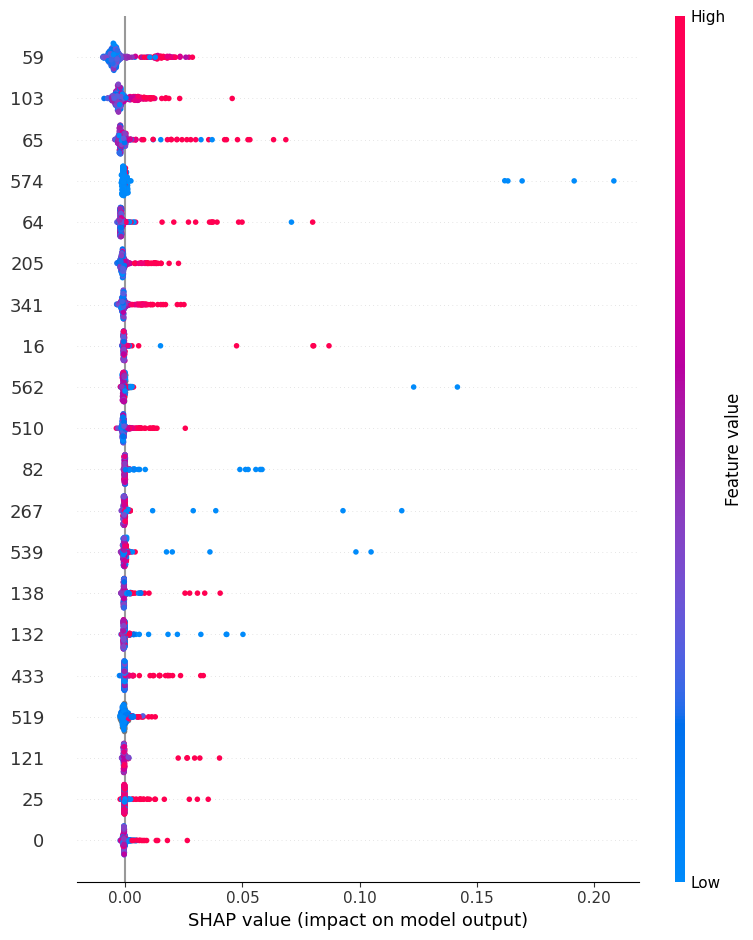

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_fail,
    X_test,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig(
    "SHAP_summary_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
top5_sensor = feature_importance.head(5)["sensor"].tolist()

top5_sensor

['64', '65', '574', '562', '59']

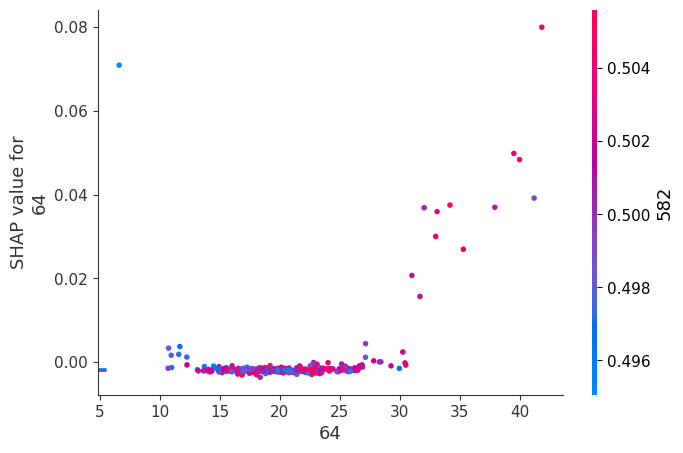

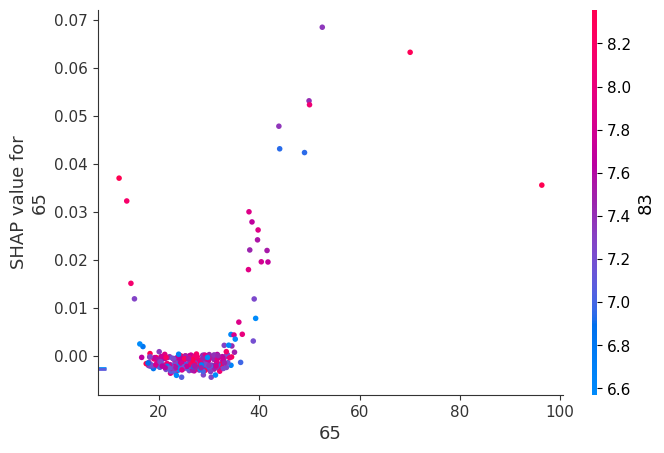

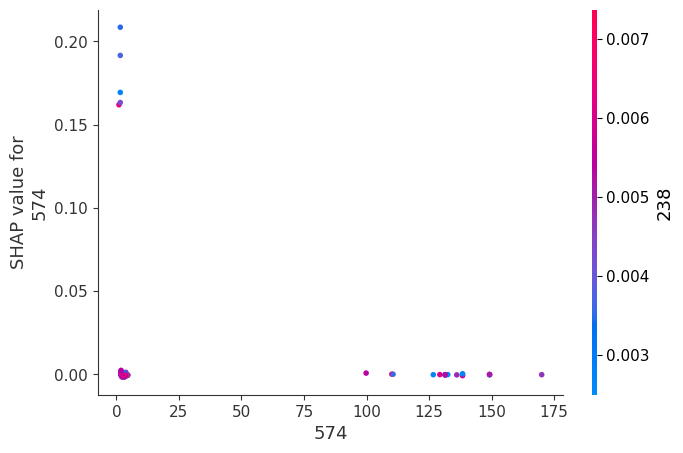

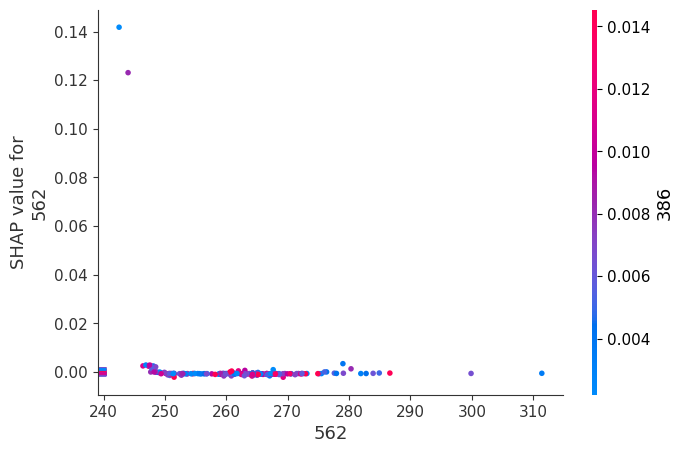

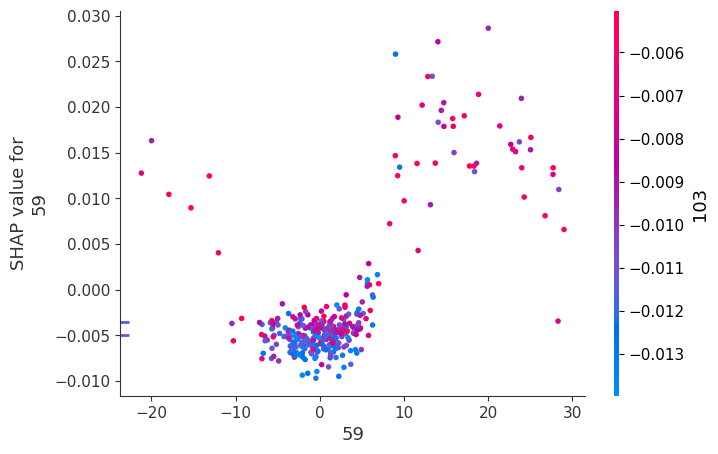

In [ ]:
for sensor in top5_sensor:
    shap.dependence_plot(
        sensor,
        shap_fail,
        X_test
    )

In [ ]:
feature_importance.head(20).to_csv(
    "RF_feature_importance_top20.csv",
    index=False
)

shap_importance.head(20).to_csv(
    "SHAP_importance_top20.csv",
    index=False
)

In [ ]:
fail_data = X_test[y_test == 1]

fail_data[top5_sensor].describe()

,64,65,574,562,59,441,103,153,26,539
count,21.000000,21.000000,21.000000,16.000000,21.000000,21.000000,21.000000,21.000000,20.000000,21.000000
mean,20.139138,26.778800,2.858190,262.618750,11.289433,0.796452,-0.008876,0.013748,1.821720,2.712452
std,6.653598,7.623275,0.529584,8.370883,9.371692,0.223644,0.002689,0.005723,0.351162,1.280083
min,6.629100,12.044600,1.887100,246.422000,-5.709100,0.481700,-0.013600,0.003700,0.891500,0.851600
25%,14.961800,21.154600,2.355500,261.215500,3.888200,0.595500,-0.010800,0.011800,1.891550,1.537100
50%,18.478200,25.983100,2.887700,264.172000,11.559100,0.789800,-0.009100,0.014500,1.980450,2.984800
75%,25.250000,32.538700,3.285000,265.986500,18.320900,1.004700,-0.006000,0.016100,1.992775,3.621300
max,34.190900,39.766100,3.708700,278.998000,26.774500,1.181500,-0.003500,0.025400,2.010500,5.046200


In [ ]:
pass_data = X_test[y_test == 0]

compare = pd.DataFrame({
    "Pass_mean": pass_data[top5_sensor].mean(),
    "Fail_mean": fail_data[top5_sensor].mean()
})

compare

,Pass_mean,Fail_mean
64,20.793862,20.139138
65,27.489120,26.778800
574,10.959118,2.858190
562,262.793574,262.618750
59,1.519022,11.289433
441,0.801459,0.796452
103,-0.009861,-0.008876
153,0.011466,0.013748
26,1.947777,1.821720
539,3.076060,2.712452


In [ ]:
shap_top5_sensor = shap_importance.head(5)["sensor"].tolist()

shap_top5_sensor

['59', '103', '65', '574', '64']

In [ ]:
extra_shap_sensor = [
    x for x in shap_top5_sensor
    if x not in top5_sensor
]

extra_shap_sensor

['103']

In [ ]:
print(top5_sensor)
print(shap_top5_sensor)

print(type(top5_sensor[0]))
print(type(shap_top5_sensor[0]))

['64', '65', '574', '562', '59']
['59', '103', '65', '574', '64']
<class 'str'>
<class 'str'>


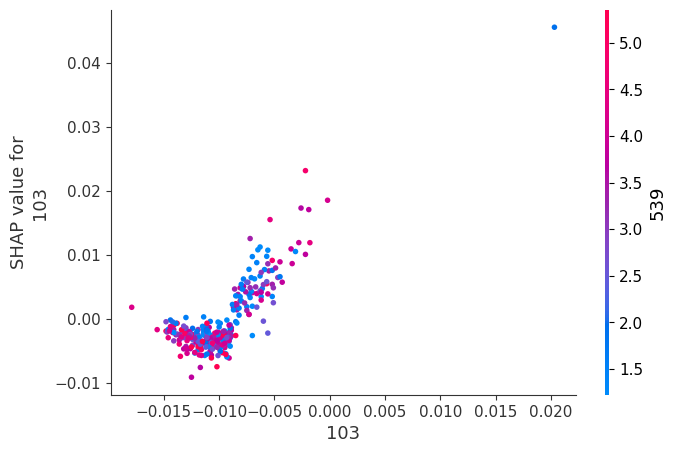

In [ ]:
for sensor in extra_shap_sensor:
    shap.dependence_plot(
        sensor,
        shap_fail,
        X_test
    )

In [ ]:
pass_data = X_test[y_test == 0]
fail_data = X_test[y_test == 1]

In [ ]:
final_sensor = ['64', '65', '574', '59', '103', '562']

compare = pd.DataFrame({
    "Pass_mean": pass_data[final_sensor].mean(),
    "Fail_mean": fail_data[final_sensor].mean(),
    "Difference": fail_data[final_sensor].mean() - pass_data[final_sensor].mean()
})

compare

,Pass_mean,Fail_mean,Difference
64,20.793862,20.139138,-0.654723
65,27.489120,26.778800,-0.710320
574,10.959118,2.858190,-8.100928
59,1.519022,11.289433,9.770412
103,-0.009861,-0.008876,0.000985
562,262.793574,262.618750,-0.174824


In [ ]:
compare.to_csv(
    "sensor_pass_fail_comparison.csv",
    encoding="utf-8-sig"
)